model de iti ghiceste ce fel de haina e in imagine

lets goo

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.ToTensor(), 
    transforms.Normalize((0.5), (0.5))
])

train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

test_dataset = datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)




100.0%
100.0%
100.0%
100.0%


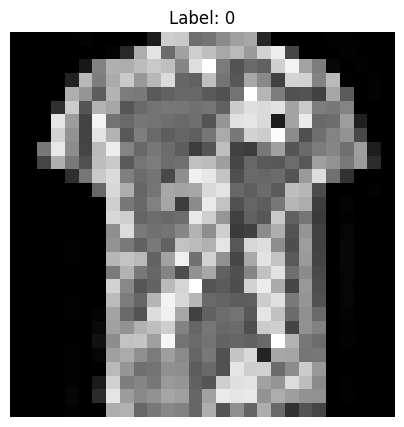

In [6]:
import matplotlib.pyplot as plt

dataiter = iter(train_loader)
images, labels = next(dataiter)

img = images[0]
label = labels[0].item()

plt.figure(figsize=(5, 5))
plt.imshow(img.squeeze(), cmap="gray")
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()


In [ ]:
import torch.nn.functional as F

class FashionMnistNN(nn.Module):
    def __init__(self):
        super(FashionMnistNN, self).__init__()

        self.flatten = nn.Flatten()
        self.hidden_layer1 = nn.Linear(28 * 28, 128)
        self.hidden_layer2 = nn.Linear(128, 64)
        self.output_layer = nn.Linear(64, 10)
    
    def forward(self, logits):
        logits = self.flatten(logits)

        logits = F.relu(self.hidden_layer1(logits))
        logits = F.relu(self.hidden_layer2(logits))

        logits = self.output_layer(logits)
        return logits
    

device = torch.device("cpu")
model = FashionMnistNN().to(device)
print("initialized model")